<a href="https://colab.research.google.com/github/JatinRaut23/Deep-Learning/blob/main/IPL_Predict.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [3]:
import numpy as np
import pandas as pd

In [4]:
match = pd.read_csv('matches.csv')
delivery = pd.read_csv('deliveries.csv')

In [5]:
match.head()

,id,Season,city,date,team1,team2,toss_winner,toss_decision,result,dl_applied,winner,win_by_runs,win_by_wickets,player_of_match,venue,umpire1,umpire2,umpire3
0,1,IPL-2017,Hyderabad,05-04-2017,Sunrisers Hyderabad,Royal Challengers Bangalore,Royal Challengers Bangalore,field,normal,0,Sunrisers Hyderabad,35,0,Yuvraj Singh,"Rajiv Gandhi International Stadium, Uppal",AY Dandekar,NJ Llong,NaN
1,2,IPL-2017,Pune,06-04-2017,Mumbai Indians,Rising Pune Supergiant,Rising Pune Supergiant,field,normal,0,Rising Pune Supergiant,0,7,SPD Smith,Maharashtra Cricket Association Stadium,A Nand Kishore,S Ravi,NaN
2,3,IPL-2017,Rajkot,07-04-2017,Gujarat Lions,Kolkata Knight Riders,Kolkata Knight Riders,field,normal,0,Kolkata Knight Riders,0,10,CA Lynn,Saurashtra Cricket Association Stadium,Nitin Menon,CK Nandan,NaN
3,4,IPL-2017,Indore,08-04-2017,Rising Pune Supergiant,Kings XI Punjab,Kings XI Punjab,field,normal,0,Kings XI Punjab,0,6,GJ Maxwell,Holkar Cricket Stadium,AK Chaudhary,C Shamshuddin,NaN
4,5,IPL-2017,Bangalore,08-04-2017,Royal Challengers Bangalore,Delhi Daredevils,Royal Challengers Bangalore,bat,normal,0,Royal Challengers Bangalore,15,0,KM Jadhav,M Chinnaswamy Stadium,NaN,NaN,NaN


In [6]:
match.shape

(756, 18)

In [7]:
delivery.head()

,match_id,inning,batting_team,bowling_team,over,ball,batsman,non_striker,bowler,is_super_over,...,bye_runs,legbye_runs,noball_runs,penalty_runs,batsman_runs,extra_runs,total_runs,player_dismissed,dismissal_kind,fielder
0,1,1,Sunrisers Hyderabad,Royal Challengers Bangalore,1.0,1.0,DA Warner,S Dhawan,TS Mills,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,NaN,NaN,NaN
1,1,1,Sunrisers Hyderabad,Royal Challengers Bangalore,1.0,2.0,DA Warner,S Dhawan,TS Mills,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,NaN,NaN,NaN
2,1,1,Sunrisers Hyderabad,Royal Challengers Bangalore,1.0,3.0,DA Warner,S Dhawan,TS Mills,0.0,...,0.0,0.0,0.0,0.0,4.0,0.0,4.0,NaN,NaN,NaN
3,1,1,Sunrisers Hyderabad,Royal Challengers Bangalore,1.0,4.0,DA Warner,S Dhawan,TS Mills,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,NaN,NaN,NaN
4,1,1,Sunrisers Hyderabad,Royal Challengers Bangalore,1.0,5.0,DA Warner,S Dhawan,TS Mills,0.0,...,0.0,0.0,0.0,0.0,0.0,2.0,2.0,NaN,NaN,NaN


In [8]:
total_score_df = delivery.groupby(['match_id','inning']).sum()['total_runs'].reset_index()

In [9]:
total_score_df = total_score_df[total_score_df['inning'] == 1]

In [10]:
total_score_df

,match_id,inning,total_runs
0,1,1,207.0
2,2,1,184.0
4,3,1,183.0
6,4,1,163.0
8,5,1,157.0
...,...,...,...
262,130,1,139.0
264,131,1,165.0
266,132,1,187.0
268,133,1,143.0


In [11]:
match_df = match.merge(total_score_df[['match_id','total_runs']],left_on='id',right_on='match_id')

In [12]:
match_df

,id,Season,city,date,team1,team2,toss_winner,toss_decision,result,dl_applied,winner,win_by_runs,win_by_wickets,player_of_match,venue,umpire1,umpire2,umpire3,match_id,total_runs
0,1,IPL-2017,Hyderabad,05-04-2017,Sunrisers Hyderabad,Royal Challengers Bangalore,Royal Challengers Bangalore,field,normal,0,Sunrisers Hyderabad,35,0,Yuvraj Singh,"Rajiv Gandhi International Stadium, Uppal",AY Dandekar,NJ Llong,NaN,1,207.0
1,2,IPL-2017,Pune,06-04-2017,Mumbai Indians,Rising Pune Supergiant,Rising Pune Supergiant,field,normal,0,Rising Pune Supergiant,0,7,SPD Smith,Maharashtra Cricket Association Stadium,A Nand Kishore,S Ravi,NaN,2,184.0
2,3,IPL-2017,Rajkot,07-04-2017,Gujarat Lions,Kolkata Knight Riders,Kolkata Knight Riders,field,normal,0,Kolkata Knight Riders,0,10,CA Lynn,Saurashtra Cricket Association Stadium,Nitin Menon,CK Nandan,NaN,3,183.0
3,4,IPL-2017,Indore,08-04-2017,Rising Pune Supergiant,Kings XI Punjab,Kings XI Punjab,field,normal,0,Kings XI Punjab,0,6,GJ Maxwell,Holkar Cricket Stadium,AK Chaudhary,C Shamshuddin,NaN,4,163.0
4,5,IPL-2017,Bangalore,08-04-2017,Royal Challengers Bangalore,Delhi Daredevils,Royal Challengers Bangalore,bat,normal,0,Royal Challengers Bangalore,15,0,KM Jadhav,M Chinnaswamy Stadium,NaN,NaN,NaN,5,157.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
129,130,IPL-2009,Cape Town,26-04-2009,Kings XI Punjab,Rajasthan Royals,Kings XI Punjab,bat,normal,0,Kings XI Punjab,27,0,KC Sangakkara,Newlands,M Erasmus,K Hariharan,NaN,130,139.0
130,131,IPL-2009,Durban,27-04-2009,Chennai Super Kings,Deccan Chargers,Deccan Chargers,field,normal,0,Deccan Chargers,0,6,HH Gibbs,Kingsmead,IL Howell,TH Wijewardene,NaN,131,165.0
131,132,IPL-2009,Port Elizabeth,27-04-2009,Mumbai Indians,Kolkata Knight Riders,Mumbai Indians,bat,normal,0,Mumbai Indians,92,0,SR Tendulkar,St George's Park,BG Jerling,RB Tiffin,NaN,132,187.0
132,133,IPL-2009,Centurion,28-04-2009,Delhi Daredevils,Rajasthan Royals,Delhi Daredevils,bat,normal,0,Rajasthan Royals,0,5,YK Pathan,SuperSport Park,GAV Baxter,RE Koertzen,NaN,133,143.0


In [13]:
match_df['team1'].unique()

array(['Sunrisers Hyderabad', 'Mumbai Indians', 'Gujarat Lions',
       'Rising Pune Supergiant', 'Royal Challengers Bangalore',
       'Kolkata Knight Riders', 'Delhi Daredevils', 'Kings XI Punjab',
       'Chennai Super Kings', 'Rajasthan Royals', 'Deccan Chargers'],
      dtype=object)

In [14]:
teams = [
    'Sunrisers Hyderabad',
    'Mumbai Indians',
    'Royal Challengers Bangalore',
    'Kolkata Knight Riders',
    'Kings XI Punjab',
    'Chennai Super Kings',
    'Rajasthan Royals',
    'Delhi Capitals'
]

In [15]:
match_df['team1'] = match_df['team1'].str.replace('Delhi Daredevils','Delhi Capitals')
match_df['team2'] = match_df['team2'].str.replace('Delhi Daredevils','Delhi Capitals')

match_df['team1'] = match_df['team1'].str.replace('Deccan Chargers','Sunrisers Hyderabad')
match_df['team2'] = match_df['team2'].str.replace('Deccan Chargers','Sunrisers Hyderabad')

In [16]:
match_df = match_df[match_df['team1'].isin(teams)]
match_df = match_df[match_df['team2'].isin(teams)]

In [17]:
match_df.shape

(106, 20)

In [18]:
match_df = match_df[match_df['dl_applied'] == 0]

In [19]:
match_df = match_df[['match_id','city','winner','total_runs']]

In [20]:
delivery_df = match_df.merge(delivery,on='match_id')

# Filter for the second inning
delivery_df = delivery_df[delivery_df['inning'] == 2]

# Convert total_runs_y to numeric, coercing errors to NaN
delivery_df['total_runs_y'] = pd.to_numeric(delivery_df['total_runs_y'], errors='coerce')

# Calculate current_score for each match
delivery_df['current_score'] = delivery_df.groupby('match_id')['total_runs_y'].cumsum()

# Calculate runs_left
delivery_df['runs_left'] = delivery_df['total_runs_x'] - delivery_df['current_score']

# Calculate balls_left (120 balls total for 20 overs, starting from 126 and decrementing by ball)
delivery_df['balls_left'] = 126 - (delivery_df['over']*6 + delivery_df['ball'])

# Correctly calculate player_dismissed (1 if dismissed, 0 otherwise)
# This uses the original 'player_dismissed' column from the merge
delivery_df['player_dismissed_int'] = delivery_df['player_dismissed'].notna().astype(int)

# Calculate wickets (remaining)
# Group by match_id to get wickets fallen per match
wickets_fallen = delivery_df.groupby('match_id')['player_dismissed_int'].cumsum()
delivery_df['wickets'] = 10 - wickets_fallen

# Calculate Current Run Rate (crr)
# Avoid division by zero for overs bowled (120 - balls_left)
delivery_df['crr'] = (delivery_df['current_score'] * 6) / (120 - delivery_df['balls_left']).replace(0, 1) # Replace 0 with 1 to avoid division by zero

# Calculate Required Run Rate (rrr)
# Avoid division by zero for balls_left
delivery_df['rrr'] = (delivery_df['runs_left'] * 6) / delivery_df['balls_left'].replace(0, 1) # Replace 0 with 1 to avoid division by zero

# Define the result function
def result(row):
    return 1 if row['batting_team'] == row['winner'] else 0

# Apply the result function
delivery_df['result'] = delivery_df.apply(result, axis=1)

# Select final features for the model
final_df = delivery_df[['batting_team','bowling_team','city','runs_left','balls_left','wickets','total_runs_x','crr','rrr','result']]

# Sample the dataframe (shuffle rows)
final_df = final_df.sample(final_df.shape[0])

# Filter out rows where balls_left is negative or zero to avoid division by zero in rrr during prediction and ensure valid ball counts
final_df = final_df[final_df['balls_left'] >= 0]
final_df = final_df[final_df['balls_left'] != 0]

# Drop any remaining NaN values (e.g., from rrr/crr calculations where balls_left or overs_bowled was 0 before handling)
final_df.dropna(inplace=True)


In [21]:
delivery_df = delivery_df[delivery_df['inning'] == 2]

In [22]:
delivery_df

,match_id,city,winner,total_runs_x,inning,batting_team,bowling_team,over,ball,batsman,...,dismissal_kind,fielder,current_score,runs_left,balls_left,player_dismissed_int,wickets,crr,rrr,result
125,1,Hyderabad,Sunrisers Hyderabad,207.0,2,Royal Challengers Bangalore,Sunrisers Hyderabad,1.0,1.0,CH Gayle,...,NaN,NaN,1.0,206.0,119.0,0,10,6.000000,10.386555,0
126,1,Hyderabad,Sunrisers Hyderabad,207.0,2,Royal Challengers Bangalore,Sunrisers Hyderabad,1.0,2.0,Mandeep Singh,...,NaN,NaN,1.0,206.0,118.0,0,10,3.000000,10.474576,0
127,1,Hyderabad,Sunrisers Hyderabad,207.0,2,Royal Challengers Bangalore,Sunrisers Hyderabad,1.0,3.0,Mandeep Singh,...,NaN,NaN,1.0,206.0,117.0,0,10,2.000000,10.564103,0
128,1,Hyderabad,Sunrisers Hyderabad,207.0,2,Royal Challengers Bangalore,Sunrisers Hyderabad,1.0,4.0,Mandeep Singh,...,NaN,NaN,3.0,204.0,116.0,0,10,4.500000,10.551724,0
129,1,Hyderabad,Sunrisers Hyderabad,207.0,2,Royal Challengers Bangalore,Sunrisers Hyderabad,1.0,5.0,Mandeep Singh,...,NaN,NaN,7.0,200.0,115.0,0,10,8.400000,10.434783,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
23572,133,Centurion,Rajasthan Royals,143.0,2,Rajasthan Royals,Delhi Daredevils,18.0,5.0,YK Pathan,...,NaN,NaN,140.0,3.0,13.0,0,5,7.850467,1.384615,1
23573,133,Centurion,Rajasthan Royals,143.0,2,Rajasthan Royals,Delhi Daredevils,18.0,6.0,YK Pathan,...,NaN,NaN,141.0,2.0,12.0,0,5,7.833333,1.000000,1
23574,133,Centurion,Rajasthan Royals,143.0,2,Rajasthan Royals,Delhi Daredevils,19.0,1.0,YK Pathan,...,NaN,NaN,141.0,2.0,11.0,0,5,7.761468,1.090909,1
23575,133,Centurion,Rajasthan Royals,143.0,2,Rajasthan Royals,Delhi Daredevils,19.0,2.0,YK Pathan,...,NaN,NaN,143.0,0.0,10.0,0,5,7.800000,0.000000,1


In [23]:
delivery_df['total_runs_y'] = pd.to_numeric(delivery_df['total_runs_y'], errors='coerce')
print(delivery_df['total_runs_y'].dtype)
delivery_df['current_score'] = delivery_df.groupby('match_id')['total_runs_y'].cumsum()

float64


In [24]:
delivery_df['runs_left'] = delivery_df['total_runs_x'] - delivery_df['current_score']

In [25]:
delivery_df['balls_left'] = 126 - (delivery_df['over']*6 + delivery_df['ball'])

In [26]:
delivery_df

,match_id,city,winner,total_runs_x,inning,batting_team,bowling_team,over,ball,batsman,...,dismissal_kind,fielder,current_score,runs_left,balls_left,player_dismissed_int,wickets,crr,rrr,result
125,1,Hyderabad,Sunrisers Hyderabad,207.0,2,Royal Challengers Bangalore,Sunrisers Hyderabad,1.0,1.0,CH Gayle,...,NaN,NaN,1.0,206.0,119.0,0,10,6.000000,10.386555,0
126,1,Hyderabad,Sunrisers Hyderabad,207.0,2,Royal Challengers Bangalore,Sunrisers Hyderabad,1.0,2.0,Mandeep Singh,...,NaN,NaN,1.0,206.0,118.0,0,10,3.000000,10.474576,0
127,1,Hyderabad,Sunrisers Hyderabad,207.0,2,Royal Challengers Bangalore,Sunrisers Hyderabad,1.0,3.0,Mandeep Singh,...,NaN,NaN,1.0,206.0,117.0,0,10,2.000000,10.564103,0
128,1,Hyderabad,Sunrisers Hyderabad,207.0,2,Royal Challengers Bangalore,Sunrisers Hyderabad,1.0,4.0,Mandeep Singh,...,NaN,NaN,3.0,204.0,116.0,0,10,4.500000,10.551724,0
129,1,Hyderabad,Sunrisers Hyderabad,207.0,2,Royal Challengers Bangalore,Sunrisers Hyderabad,1.0,5.0,Mandeep Singh,...,NaN,NaN,7.0,200.0,115.0,0,10,8.400000,10.434783,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
23572,133,Centurion,Rajasthan Royals,143.0,2,Rajasthan Royals,Delhi Daredevils,18.0,5.0,YK Pathan,...,NaN,NaN,140.0,3.0,13.0,0,5,7.850467,1.384615,1
23573,133,Centurion,Rajasthan Royals,143.0,2,Rajasthan Royals,Delhi Daredevils,18.0,6.0,YK Pathan,...,NaN,NaN,141.0,2.0,12.0,0,5,7.833333,1.000000,1
23574,133,Centurion,Rajasthan Royals,143.0,2,Rajasthan Royals,Delhi Daredevils,19.0,1.0,YK Pathan,...,NaN,NaN,141.0,2.0,11.0,0,5,7.761468,1.090909,1
23575,133,Centurion,Rajasthan Royals,143.0,2,Rajasthan Royals,Delhi Daredevils,19.0,2.0,YK Pathan,...,NaN,NaN,143.0,0.0,10.0,0,5,7.800000,0.000000,1


In [27]:
delivery_df['player_dismissed'] = delivery_df['player_dismissed'].notna().astype(int)

wickets = delivery_df.groupby('match_id')['player_dismissed'].cumsum().values
delivery_df['wickets'] = 10 - wickets

In [28]:
delivery_df['total_runs_y'] = pd.to_numeric(delivery_df['total_runs_y'], errors='coerce')
print(delivery_df['total_runs_y'].dtype)
delivery_df['current_score'] = delivery_df.groupby('match_id')['total_runs_y'].cumsum()

float64


In [29]:
delivery_df['runs_left'] = delivery_df['total_runs_x'] - delivery_df['current_score']

In [30]:
delivery_df['balls_left'] = 126 - (delivery_df['over']*6 + delivery_df['ball'])

In [31]:
delivery_df

,match_id,city,winner,total_runs_x,inning,batting_team,bowling_team,over,ball,batsman,...,dismissal_kind,fielder,current_score,runs_left,balls_left,player_dismissed_int,wickets,crr,rrr,result
125,1,Hyderabad,Sunrisers Hyderabad,207.0,2,Royal Challengers Bangalore,Sunrisers Hyderabad,1.0,1.0,CH Gayle,...,NaN,NaN,1.0,206.0,119.0,0,10,6.000000,10.386555,0
126,1,Hyderabad,Sunrisers Hyderabad,207.0,2,Royal Challengers Bangalore,Sunrisers Hyderabad,1.0,2.0,Mandeep Singh,...,NaN,NaN,1.0,206.0,118.0,0,10,3.000000,10.474576,0
127,1,Hyderabad,Sunrisers Hyderabad,207.0,2,Royal Challengers Bangalore,Sunrisers Hyderabad,1.0,3.0,Mandeep Singh,...,NaN,NaN,1.0,206.0,117.0,0,10,2.000000,10.564103,0
128,1,Hyderabad,Sunrisers Hyderabad,207.0,2,Royal Challengers Bangalore,Sunrisers Hyderabad,1.0,4.0,Mandeep Singh,...,NaN,NaN,3.0,204.0,116.0,0,10,4.500000,10.551724,0
129,1,Hyderabad,Sunrisers Hyderabad,207.0,2,Royal Challengers Bangalore,Sunrisers Hyderabad,1.0,5.0,Mandeep Singh,...,NaN,NaN,7.0,200.0,115.0,0,10,8.400000,10.434783,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
23572,133,Centurion,Rajasthan Royals,143.0,2,Rajasthan Royals,Delhi Daredevils,18.0,5.0,YK Pathan,...,NaN,NaN,140.0,3.0,13.0,0,5,7.850467,1.384615,1
23573,133,Centurion,Rajasthan Royals,143.0,2,Rajasthan Royals,Delhi Daredevils,18.0,6.0,YK Pathan,...,NaN,NaN,141.0,2.0,12.0,0,5,7.833333,1.000000,1
23574,133,Centurion,Rajasthan Royals,143.0,2,Rajasthan Royals,Delhi Daredevils,19.0,1.0,YK Pathan,...,NaN,NaN,141.0,2.0,11.0,0,5,7.761468,1.090909,1
23575,133,Centurion,Rajasthan Royals,143.0,2,Rajasthan Royals,Delhi Daredevils,19.0,2.0,YK Pathan,...,NaN,NaN,143.0,0.0,10.0,0,5,7.800000,0.000000,1


In [32]:
delivery_df['player_dismissed'] = delivery_df['player_dismissed'].notna().astype(int)
wickets = delivery_df.groupby('match_id')['player_dismissed'].cumsum().values
delivery_df['wickets'] = 10 - wickets

In [33]:
delivery_df.head()

,match_id,city,winner,total_runs_x,inning,batting_team,bowling_team,over,ball,batsman,...,dismissal_kind,fielder,current_score,runs_left,balls_left,player_dismissed_int,wickets,crr,rrr,result
125,1,Hyderabad,Sunrisers Hyderabad,207.0,2,Royal Challengers Bangalore,Sunrisers Hyderabad,1.0,1.0,CH Gayle,...,NaN,NaN,1.0,206.0,119.0,0,9,6.0,10.386555,0
126,1,Hyderabad,Sunrisers Hyderabad,207.0,2,Royal Challengers Bangalore,Sunrisers Hyderabad,1.0,2.0,Mandeep Singh,...,NaN,NaN,1.0,206.0,118.0,0,8,3.0,10.474576,0
127,1,Hyderabad,Sunrisers Hyderabad,207.0,2,Royal Challengers Bangalore,Sunrisers Hyderabad,1.0,3.0,Mandeep Singh,...,NaN,NaN,1.0,206.0,117.0,0,7,2.0,10.564103,0
128,1,Hyderabad,Sunrisers Hyderabad,207.0,2,Royal Challengers Bangalore,Sunrisers Hyderabad,1.0,4.0,Mandeep Singh,...,NaN,NaN,3.0,204.0,116.0,0,6,4.5,10.551724,0
129,1,Hyderabad,Sunrisers Hyderabad,207.0,2,Royal Challengers Bangalore,Sunrisers Hyderabad,1.0,5.0,Mandeep Singh,...,NaN,NaN,7.0,200.0,115.0,0,5,8.4,10.434783,0


In [34]:
# crr = runs/overs
delivery_df['crr'] = (delivery_df['current_score']*6)/(120 - delivery_df['balls_left'])

In [35]:
delivery_df['rrr'] = (delivery_df['runs_left']*6)/delivery_df['balls_left']

In [36]:
def result(row):
    return 1 if row['batting_team'] == row['winner'] else 0

In [37]:
delivery_df['result'] = delivery_df.apply(result,axis=1)

In [38]:
final_df = delivery_df[['batting_team','bowling_team','city','runs_left','balls_left','wickets','total_runs_x','crr','rrr','result']]

In [39]:
final_df = final_df.sample(final_df.shape[0])

In [40]:
final_df.sample()

,batting_team,bowling_team,city,runs_left,balls_left,wickets,total_runs_x,crr,rrr,result
14245,Mumbai Indians,Royal Challengers Bangalore,Bangalore,62.0,71.0,-44,122.0,7.346939,5.239437,1


In [41]:
final_df.dropna(inplace=True)

In [42]:
final_df = final_df[final_df['balls_left'] != 0]

In [43]:
X = final_df.iloc[:,:-1]
y = final_df.iloc[:,-1]
from sklearn.model_selection import train_test_split
X_train,X_test,y_train,y_test = train_test_split(X,y,test_size=0.2,random_state=1)

In [44]:
X_train

,batting_team,bowling_team,city,runs_left,balls_left,wickets,total_runs_x,crr,rrr
13361,Mumbai Indians,Rajasthan Royals,Mumbai,53.0,68.0,-45,103.0,5.769231,4.676471
6808,Delhi Daredevils,Royal Challengers Bangalore,Delhi,54.0,26.0,-86,161.0,6.829787,12.461538
13533,Chennai Super Kings,Delhi Daredevils,Delhi,183.0,118.0,8,187.0,12.000000,9.305085
5721,Sunrisers Hyderabad,Mumbai Indians,Hyderabad,138.0,119.0,9,138.0,0.000000,6.957983
3553,Royal Challengers Bangalore,Kolkata Knight Riders,Kolkata,91.0,82.0,-31,131.0,6.315789,6.658537
...,...,...,...,...,...,...,...,...,...
9599,Rajasthan Royals,Royal Challengers Bangalore,Bangalore,66.0,64.0,-47,135.0,7.392857,6.187500
9800,Chennai Super Kings,Kolkata Knight Riders,Chennai,122.0,95.0,-17,147.0,6.000000,7.705263
15444,Delhi Daredevils,Kolkata Knight Riders,Kolkata,79.0,70.0,-42,133.0,6.480000,6.771429
19716,Delhi Daredevils,Rajasthan Royals,Mumbai,153.0,74.0,-39,192.0,5.086957,12.405405


In [45]:
def match_summary(row):
    print("Batting Team-" + row['batting_team'] + " | Bowling Team-" + row['bowling_team'] + " | Target- " + str(row['total_runs_x']))

In [46]:
def match_progression(x_df,match_id,pipe):
    match = x_df[x_df['match_id'] == match_id]
    match = match[(match['ball'] == 6)]
    temp_df = match[['batting_team','bowling_team','city','runs_left','balls_left','wickets','total_runs_x','crr','rrr']].dropna()
    temp_df = temp_df[temp_df['balls_left'] != 0]
    result = pipe.predict_proba(temp_df)
    temp_df['lose'] = np.round(result.T[0]*100,1)
    temp_df['win'] = np.round(result.T[1]*100,1)
    temp_df['end_of_over'] = range(1,temp_df.shape[0]+1)

    target = temp_df['total_runs_x'].values[0]
    runs = list(temp_df['runs_left'].values)
    new_runs = runs[:]
    runs.insert(0,target)
    temp_df['runs_after_over'] = np.array(runs)[:-1] - np.array(new_runs)
    wickets = list(temp_df['wickets'].values)
    new_wickets = wickets[:]
    new_wickets.insert(0,10)
    w = np.array(wickets)
    nw = np.array(new_wickets)
    temp_df['wickets_in_over'] = (nw - w)[0:temp_df.shape[0]]

    print("Target-",target)
    temp_df = temp_df[['end_of_over','runs_after_over','wickets_in_over','lose','win']]
    return temp_df,target

In [47]:
teams

['Sunrisers Hyderabad',
 'Mumbai Indians',
 'Royal Challengers Bangalore',
 'Kolkata Knight Riders',
 'Kings XI Punjab',
 'Chennai Super Kings',
 'Rajasthan Royals',
 'Delhi Capitals']

In [48]:
delivery_df['city'].unique()

array(['Hyderabad', 'Bangalore', 'Mumbai', 'Indore', 'Kolkata', 'Delhi',
       'Chandigarh', 'Jaipur', 'Chennai', 'Cape Town', 'Port Elizabeth',
       'Durban', 'Centurion'], dtype=object)

In [49]:
print('Unique values in player_dismissed before conversion:')
display(delivery_df['player_dismissed'].unique())

print('Are there any empty strings in player_dismissed?')
display(delivery_df['player_dismissed'].apply(lambda x: isinstance(x, str) and x == '').any())

Unique values in player_dismissed before conversion:


array([1])

Are there any empty strings in player_dismissed?


np.False_

In [50]:
delivery_df.head()

,match_id,city,winner,total_runs_x,inning,batting_team,bowling_team,over,ball,batsman,...,dismissal_kind,fielder,current_score,runs_left,balls_left,player_dismissed_int,wickets,crr,rrr,result
125,1,Hyderabad,Sunrisers Hyderabad,207.0,2,Royal Challengers Bangalore,Sunrisers Hyderabad,1.0,1.0,CH Gayle,...,NaN,NaN,1.0,206.0,119.0,0,9,6.0,10.386555,0
126,1,Hyderabad,Sunrisers Hyderabad,207.0,2,Royal Challengers Bangalore,Sunrisers Hyderabad,1.0,2.0,Mandeep Singh,...,NaN,NaN,1.0,206.0,118.0,0,8,3.0,10.474576,0
127,1,Hyderabad,Sunrisers Hyderabad,207.0,2,Royal Challengers Bangalore,Sunrisers Hyderabad,1.0,3.0,Mandeep Singh,...,NaN,NaN,1.0,206.0,117.0,0,7,2.0,10.564103,0
128,1,Hyderabad,Sunrisers Hyderabad,207.0,2,Royal Challengers Bangalore,Sunrisers Hyderabad,1.0,4.0,Mandeep Singh,...,NaN,NaN,3.0,204.0,116.0,0,6,4.5,10.551724,0
129,1,Hyderabad,Sunrisers Hyderabad,207.0,2,Royal Challengers Bangalore,Sunrisers Hyderabad,1.0,5.0,Mandeep Singh,...,NaN,NaN,7.0,200.0,115.0,0,5,8.4,10.434783,0


In [51]:
import tensorflow as tf
from tensorflow import keras
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline

# Define categorical and numerical features
categorical_features = ['batting_team', 'bowling_team', 'city']
numerical_features = ['runs_left', 'balls_left', 'wickets', 'total_runs_x', 'crr', 'rrr']

# Create a column transformer for preprocessing
preprocessor = ColumnTransformer(
    transformers=[
        ('num', StandardScaler(), numerical_features),
        ('cat', OneHotEncoder(handle_unknown='ignore', sparse_output=False), categorical_features)
    ],
    remainder='passthrough'
)

# Fit and transform X_train and X_test using the preprocessor
X_train_processed = preprocessor.fit_transform(X_train)
X_test_processed = preprocessor.transform(X_test)

# Define the ANN model
# Adjust input_shape based on the output of the preprocessor
model = keras.Sequential([
    keras.layers.Dense(128, activation='relu', input_shape=(X_train_processed.shape[1],)),
    keras.layers.Dropout(0.3),
    keras.layers.Dense(64, activation='relu'),
    keras.layers.Dropout(0.3),
    keras.layers.Dense(32, activation='relu'),
    keras.layers.Dense(1, activation='sigmoid') # Output layer for binary classification
])

# Compile the model (before training)
model.compile(optimizer='adam', loss='binary_crossentropy', metrics=['accuracy'])

# Train the model with preprocessed data
model.fit(X_train_processed, y_train, epochs=10, batch_size=32, verbose=1)

# Evaluate the model with preprocessed data
loss, accuracy = model.evaluate(X_test_processed, y_test, verbose=0)
print(f"Test Loss: {loss:.4f}")
print(f"Test Accuracy: {accuracy:.4f}")


/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Epoch 1/10
281/281 ━━━━━━━━━━━━━━━━━━━━ 6s 9ms/step - accuracy: 0.8817 - loss: 0.2812
Epoch 2/10
281/281 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.9855 - loss: 0.0515
Epoch 3/10
281/281 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.9941 - loss: 0.0192
Epoch 4/10
281/281 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.9979 - loss: 0.0089
Epoch 5/10
281/281 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.9978 - loss: 0.0071
Epoch 6/10
281/281 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.9981 - loss: 0.0062
Epoch 7/10
281/281 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.9984 - loss: 0.0056
Epoch 8/10
281/281 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.9989 - loss: 0.0034
Epoch 9/10
281/281 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.9987 - loss: 0.0037
Epoch 10/10
281/281 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.9984 - loss: 0.0054
Test Loss: 0.0004
Test Accuracy: 1.0000


In [52]:
# Test the model with a sample input
# Let's take the first row from X_test as an example
sample_input_df = X_test.iloc[[6]]

# Preprocess the sample input
sample_input_processed = preprocessor.transform(sample_input_df)

# Make a prediction
prediction = model.predict(sample_input_processed)

print(f"Sample Input:\n{sample_input_df}")
print(f"\nPredicted Winning Probability for Batting Team: {prediction[0][0]:.4f}")

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 431ms/step
Sample Input:
           batting_team                 bowling_team            city  \
22524  Delhi Daredevils  Royal Challengers Bangalore  Port Elizabeth   

       runs_left  balls_left  wickets  total_runs_x       crr       rrr  
22524      112.0        93.0      -18         149.0  8.222222  7.225806  

Predicted Winning Probability for Batting Team: 1.0000


In [53]:
import pickle

# Save the preprocessor
with open('preprocessor.pkl', 'wb') as f:
    pickle.dump(preprocessor, f)
print("Preprocessor saved as preprocessor.pkl")

# Save the Keras model
model.save('ann_model.h5')
print("Keras model saved as ann_model.h5")

Preprocessor saved as preprocessor.pkl
Keras model saved as ann_model.h5


Overall Test Accuracy: 1.0000
71/71 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step


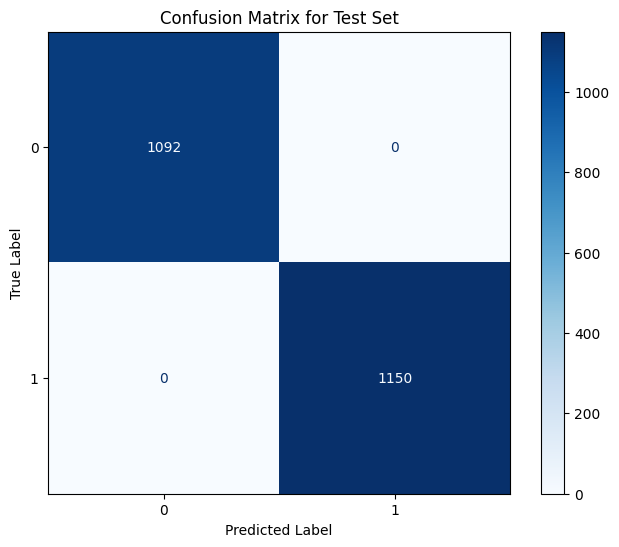

In [54]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
import matplotlib.pyplot as plt

# Evaluate the model on the test set (if not already done)
loss, accuracy = model.evaluate(X_test_processed, y_test, verbose=0)
print(f"Overall Test Accuracy: {accuracy:.4f}")

# Get predictions for the test set
y_pred_proba = model.predict(X_test_processed).flatten()
y_pred = (y_pred_proba > 0.5).astype(int) # Convert probabilities to binary predictions (0 or 1)

# Generate the confusion matrix
cm = confusion_matrix(y_test, y_pred)

# Display the confusion matrix
fig, ax = plt.subplots(figsize=(8, 6))
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=[0, 1])
disp.plot(cmap=plt.cm.Blues, ax=ax)
plt.title('Confusion Matrix for Test Set')
plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.show()